In [23]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2024_Phase_Camera_FM_Design/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2

from scipy.signal import correlate2d
from scipy.interpolate import RegularGridInterpolator

* *Ensuring proper sampling, wavefield size, and boundary conditions*
* Simulate and save phase mask with proper sizes
    * Try different densities of structures
    * Compare outputs from different samplings
* Ensure proper simulation w.r.t. medium RIs
* *Compare BPM vs Thin sample modeling*
    * Make videos for propagation distances
* Problem specification: FOV and same sampling, but spatial resolution/ spatial frequency limited by distance and speckle size?
    * Speckle size increases with distance?

In [8]:
### coded wfs sensing data creation.

# reference
geom1 = utils.load_pkl('data/geometry/v4_diffuser_geom.pkl')
print(f"Loaded object 1: {geom1}")

RI_dist = geom1.get_grid()[:, :, :-400]
nx, ny, nz = geom1.nx, geom1.ny, geom1.nz
dx, dy, dz = geom1.dx, geom1.dy, geom1.dz
n_background = geom1.n_0
wl =  530e-9
NA = 1.15
M = 10
n_m = 1.

Loading geometry object...
Loaded object 1: Coordiante system with size: 
 
              X = [0, 2.50e-05], Res_X = 5e-08
              Y = [0, 2.50e-05], Res_Y = 5e-08
              Z = [0, 2.50e-05], Res_Z = 5e-08
              Immersion RI: 1
              


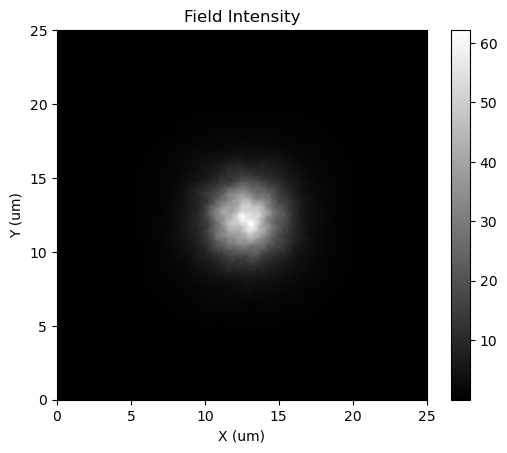

In [9]:
# visualization.visualize_grid_vol(RI_dist, n_background=n_background, factor=2)

# Initial light field
# field = np.ones([nx, ny])*80
field = np.zeros([nx, ny])
field[250:260, 250:260] = 80
# field[240, 240] = 80

# Propagate and visualize
output_field = propagator.propagate_beam_2(field, RI_dist, n_background, wl, [dx, dy, dz])
# output_field = propagator.propagate(output_field, wl, [dx, dy, dz], 1e-4)

visualization.visualize_field(output_field, [dx*nx, dy*ny])

# tifffile.imwrite('data/speckles/v6_ref.tif', (np.abs(output_field)**2).astype(np.uint16))

In [11]:
RI_dist.shape, np.unique(RI_dist[:, :, 50]), np.unique(RI_dist[:, :, 60]), np.unique(RI_dist)

((500, 500, 100),
 array([1.    , 1.4609]),
 array([1.49]),
 array([1.    , 1.4609, 1.49  ]))

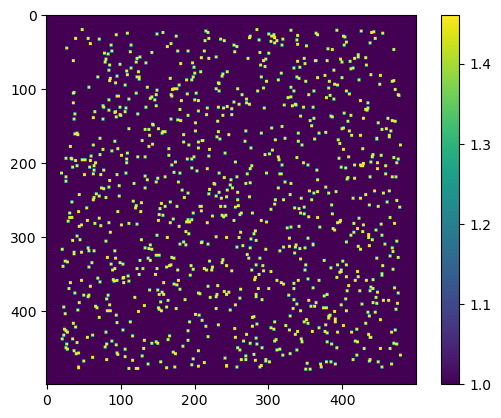

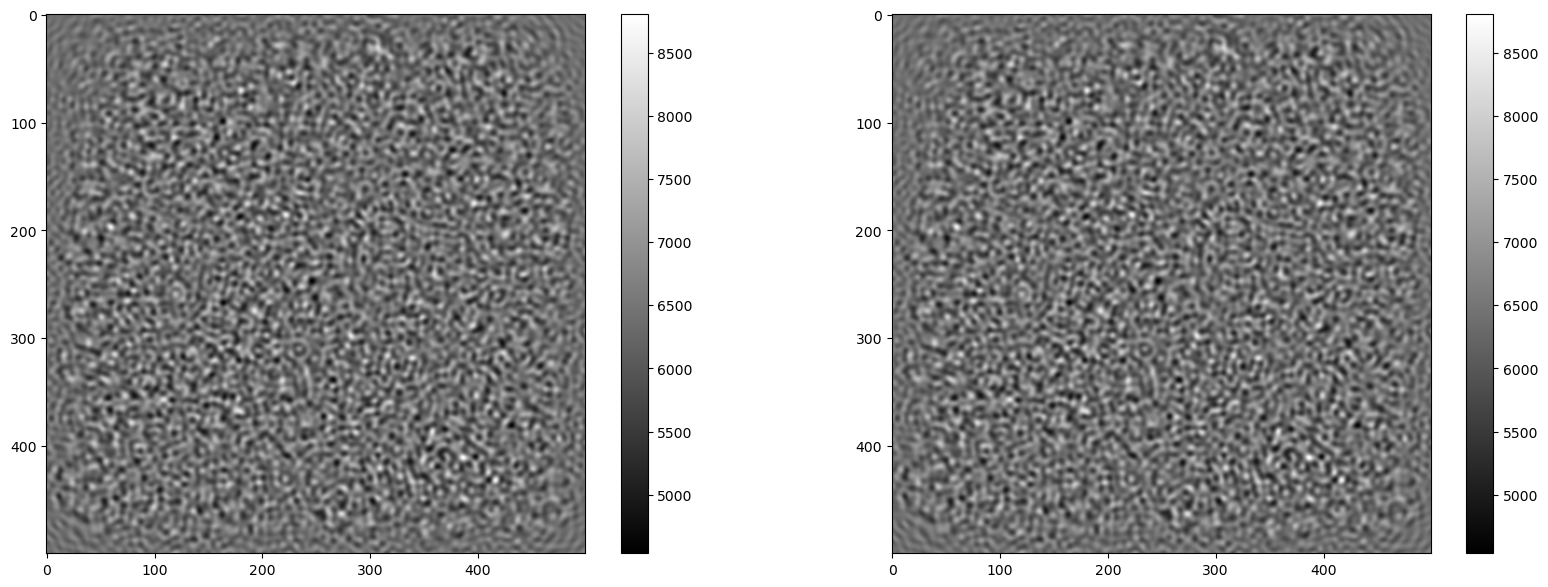

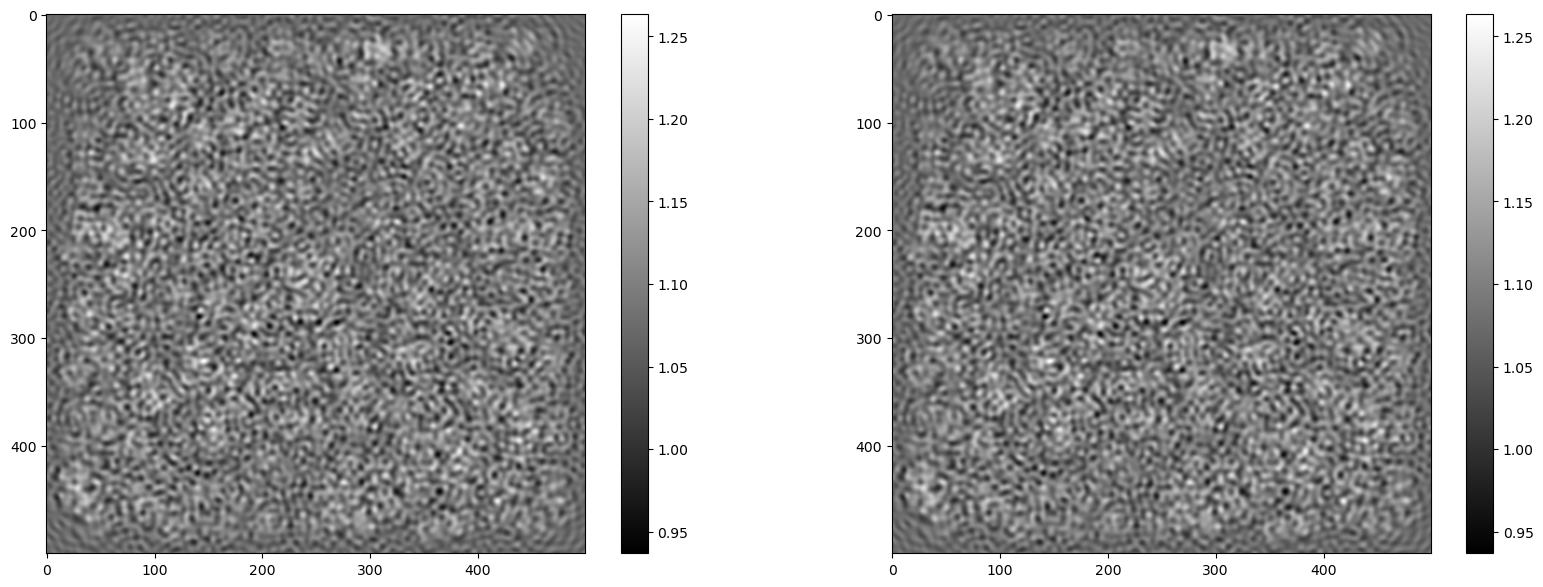

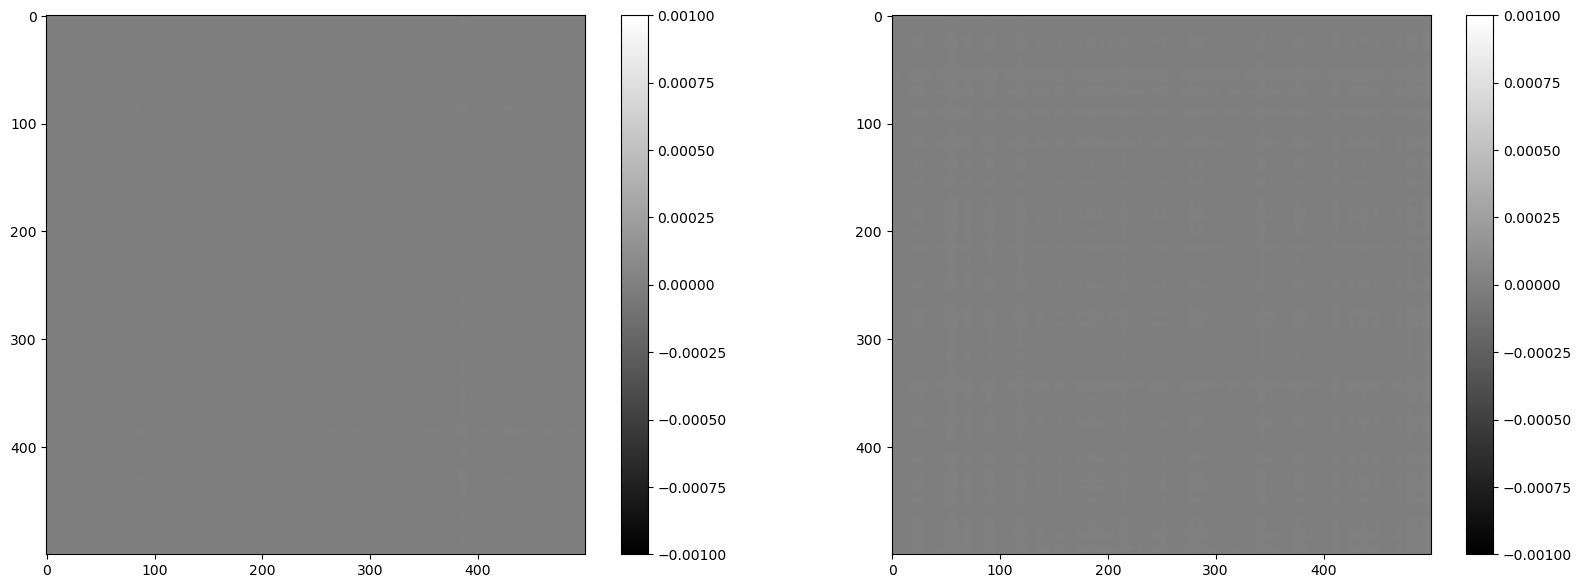

In [16]:
RI_dist = geom1.get_grid()[:, :, 50:80]
field = np.zeros([nx, ny])
field[:, :] = 80

plt.imshow(RI_dist[:, :, 0])
plt.colorbar()
plt.show()

# Propagate and visualize
output_field = propagator.propagate_beam_2(field, RI_dist, 1.49, wl, [dx, dy, dz], padding=512)

phase_delay = RI_dist[:, :, 0]*50e-9*-1
output_field_2 = propagator.propagate(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 - 50e-9, padding=512)
# *np.exp(-1j*(2*np.pi/wl)*50*50e-9)

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(output_field_2)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.angle(output_field), cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field_2), cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field) - np.abs(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field) - np.angle(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
plt.colorbar(cm1, ax=axs[1])

plt.show()

(1012, 1012)

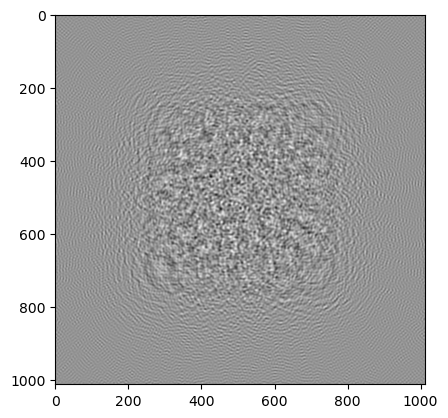

In [27]:
output_field_2_check = propagator.propagate(np.pad(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), 256, 'edge'), 
                                            wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 + 10e-6, padding=None)

plt.imshow(np.abs(output_field_2_check), cmap='gray')
output_field_2_check.shape

In [ ]:
# cap = cv2.VideoCapture(0)

# # Define the codec and create VideoWriter object
# #fourcc = cv2.cv.CV_FOURCC(*'DIVX')
# #out = cv2.VideoWriter('output.avi',fourcc, 20.0, (640,480))
# out = cv2.VideoWriter('mask_prop_abs.avi', cv2.VideoWriter_fourcc(*'XVID'), 20, (1012, 1012), isColor=False)

# for i in range(100):
#     frame = propagator.propagate(np.pad(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), 256, 'edge'), 
#                                  wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 + i*1e-6, padding=None)
    
#     frame = np.abs(frame)
#     frame = np.array(((frame - frame.min())/(frame.max() - frame.min()))*255, dtype=np.uint8)

#     # write the flipped frame
#     out.write(frame)

# # Release everything if job is finished
# out.release()